## Demo notebook

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

notebook_path = Path().absolute()
project_root = notebook_path.parent
sys.path.append(str(project_root))
from src.data_utils import SCGDataLoader

In [3]:
data_loader = SCGDataLoader()

In [4]:
data = data_loader.load_data()

In [5]:
%matplotlib inline

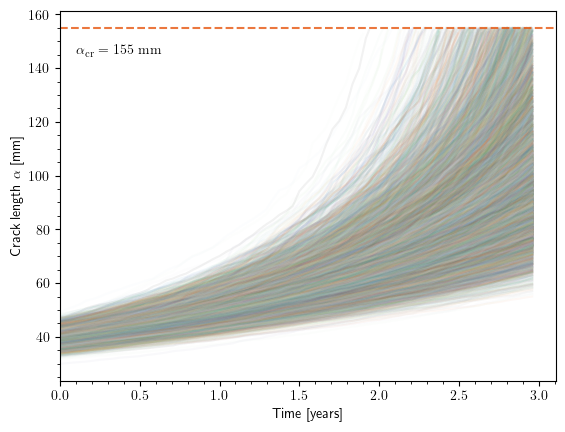

In [6]:
from src.visualisation import plot_scg_data

plot_scg_data(data["times"], data["crack_lengths"], save_fig_name="scg_data.pdf")

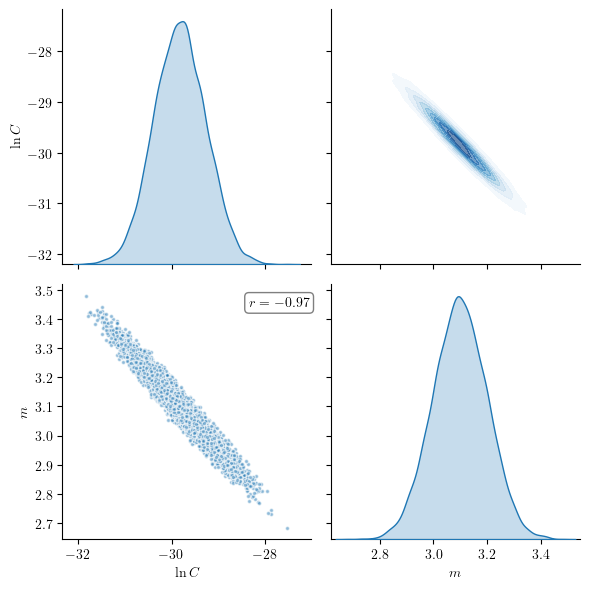

In [7]:
from src.visualisation import paris_params_pair_plot
paris_params_pair_plot(data["paris_c"], data["paris_m"], save_fig_name="paris_params_pair_plot.pdf")

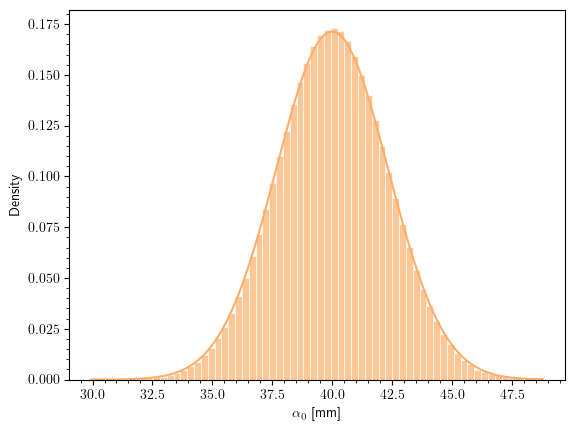

In [8]:
from src.visualisation import plot_initial_crack_length
plot_initial_crack_length(data["initial_crack_length"], save_fig_name="a0_hist.pdf")

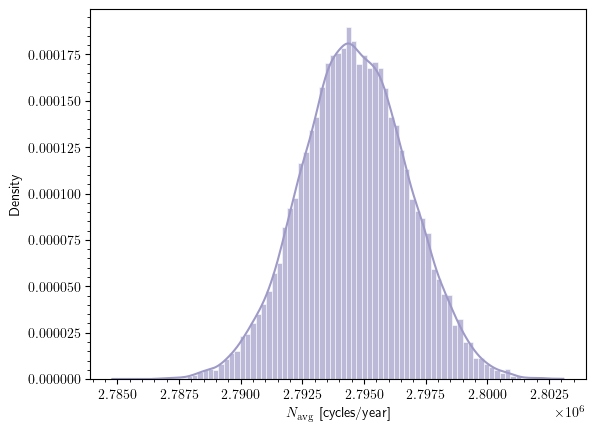

In [13]:
from src.visualisation import plot_avg_cycles
plot_avg_cycles(data["avg_cycles"], save_fig_name="avg_cycles_hist.pdf")

In [14]:
print(f"Average equivalent number of cycles for an approx. 3-year span: {data['avg_cycles'].mean() * data['times'].max():.2f}")
print(f"Assuming an 8-second average period, this is approximately {data['avg_cycles'].mean() * data['times'].max() * 8 / 3600:.2f} hours of operation.")
print(f"Or approximately {data['avg_cycles'].mean() * data['times'].max() * 8 / 3600 / (365 * 24):.2f} years of operation.")

Average equivalent number of cycles for an approx. 3-year span: 8268437.54
Assuming an 8-second average period, this is approximately 18374.31 hours of operation.
Or approximately 2.10 years of operation.


In [15]:
print(f"""Based on the data, the average period is approximately:
{(3*365.25*24*60*60)/(data['avg_cycles'].mean() * data['times'].max()):.2f} seconds.""")

Based on the data, the average period is approximately:
11.45 seconds.


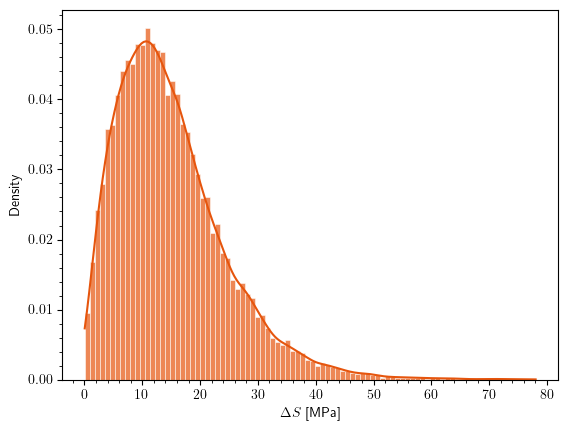

In [12]:
from src.visualisation import plot_stress_ranges
plot_stress_ranges(data["stress_ranges"], save_fig_name="stress_ranges_hist.pdf")

In [16]:
from src.visualisation import plot_paris_predictions
import numpy as np

In [17]:
# Randomly select instances to test the Paris law predictions
instances = np.random.randint(low=0, high=(data["times"].shape[0] - 1), size=10)
# Get the Paris law parameters for these instances
paris_params = (data["paris_c"][instances], data["paris_m"][instances])
# Get the initial crack lengths for these instances
initial_crack_lengths = data["initial_crack_length"][instances]
# Get the stress ranges for these instances
stress_ranges = np.linspace(10, 40, instances.shape[0])
# Use a common time array for all instances - using the first row of times
time_array = data["times"][0]
# Create array with the number of cycles for each instance
n_cycles = np.ones(instances.shape[0]) * np.mean(data["avg_cycles"][:, 0])

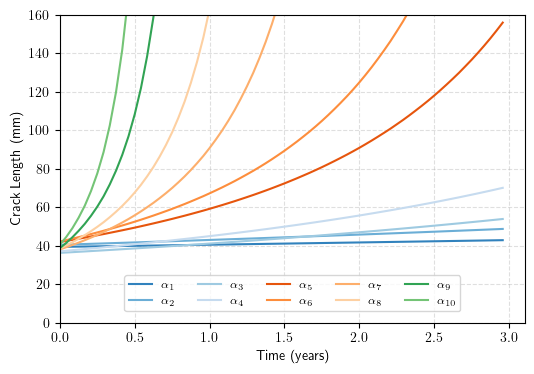

In [18]:
# Use our refactored function for plotting
fig, ax = plot_paris_predictions(
    paris_params=paris_params,
    ds=stress_ranges,
    navg=n_cycles,
    a0=initial_crack_lengths,
    times=time_array,
    save_fig_name="paris_predictions.pdf",
    figsize=(6, 4),
    plot_grid=True
)

# We can add additional customization if needed
#ax.set_title("Paris Law Crack Growth Predictions for Multiple Instances")

Parameters for instance 9899:
logC: -30.2271
m: 3.1494
ds: 23.3333
navg: 2793155.5950
a0: 41.8680


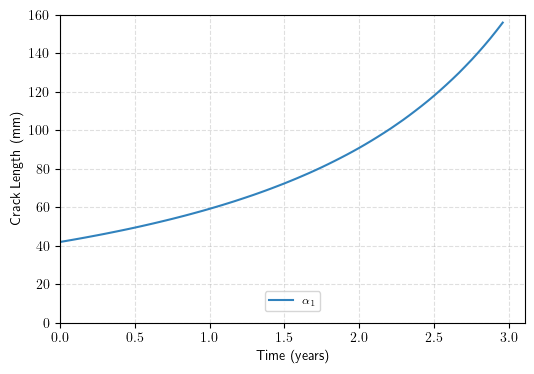

In [19]:
# Let's also test a single prediction to understand what's going on
inst = instances[4]
c = paris_params[0][4]
m = paris_params[1][4]
ds = stress_ranges[4]
navg = n_cycles[4]
a0 = initial_crack_lengths[4]

# Print these values to debug
print(f"Parameters for instance {inst}:")
print(f"logC: {np.log(c):.4f}")
print(f"m: {m:.4f}")
print(f"ds: {ds:.4f}")
print(f"navg: {navg:.4f}")
print(f"a0: {a0:.4f}")

# Plot a single instance prediction
fig, ax = plot_paris_predictions(
    paris_params=(c, m),
    ds=ds,
    navg=navg,
    a0=a0,
    times=time_array,
    figsize=(6, 4)
)

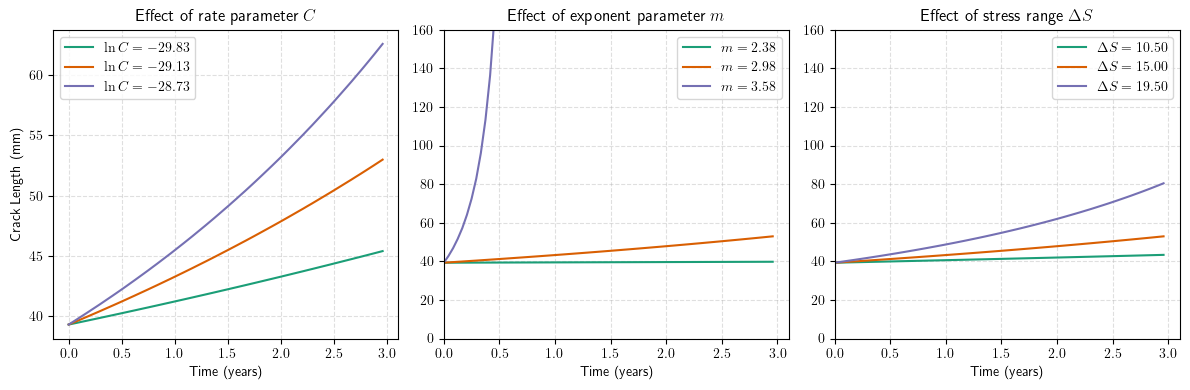

In [20]:
# Let's also explore how different parameters affect crack growth
from src.visualisation import plot_parameter_sensitivity

# Create baseline parameters
base_c = paris_params[0][0]
base_m = paris_params[1][0]
base_ds = 15.0
base_navg = n_cycles[0]
base_a0 = initial_crack_lengths[0]

# Use the new modular function for parameter sensitivity analysis
fig, axes = plot_parameter_sensitivity(
    base_c=base_c,
    base_m=base_m,
    base_ds=base_ds,
    base_navg=base_navg,
    base_a0=base_a0,
    times=time_array,
    save_fig_name="parameter_sensitivity.pdf",
)

# You can still customize the plot if needed
# axes[1].set_ylim(bottom=0, top=160)

## Testing Variable Stress Paris-Erdogan Model

This section demonstrates how to use the `VariableStressParisErdogan` model for simulating crack growth with time-varying stress ranges.

Average stress: 17.00 MPa
Stress range: 5.0 - 30.0 MPa


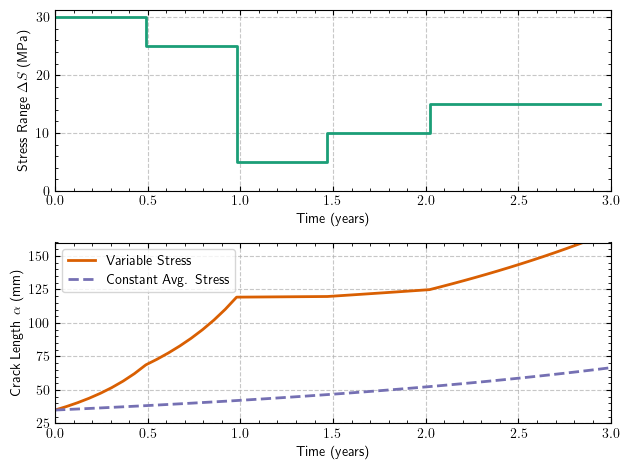

In [21]:
from src.visualisation import plot_variable_stress_comparison

# Define custom stress periods
stress_periods = [
    (0.0, 0.5, 30.0),
    (0.5, 1.0, 25.0),
    (1.0, 1.5, 5.0),
    (1.5, 2.0, 10.0),
    (2.0, 3.0, 15.0),
]

# Use the new visualization function
fig, axs = plot_variable_stress_comparison(
    stress_periods=stress_periods,
    logc=np.log(1e-13),
    m=3.2,
    navg=3e6,
    a0=35.0,
    cmap_name='Dark2',
    figsize=(6.4, 4.8),
    save_fig_name="variable_stress_comparison.pdf"
)

# Print some interesting statistics about the plot
print(f"Average stress: {np.mean([s[2] for s in stress_periods]):.2f} MPa")
print(f"Stress range: {min([s[2] for s in stress_periods]):.1f} - {max([s[2] for s in stress_periods]):.1f} MPa")

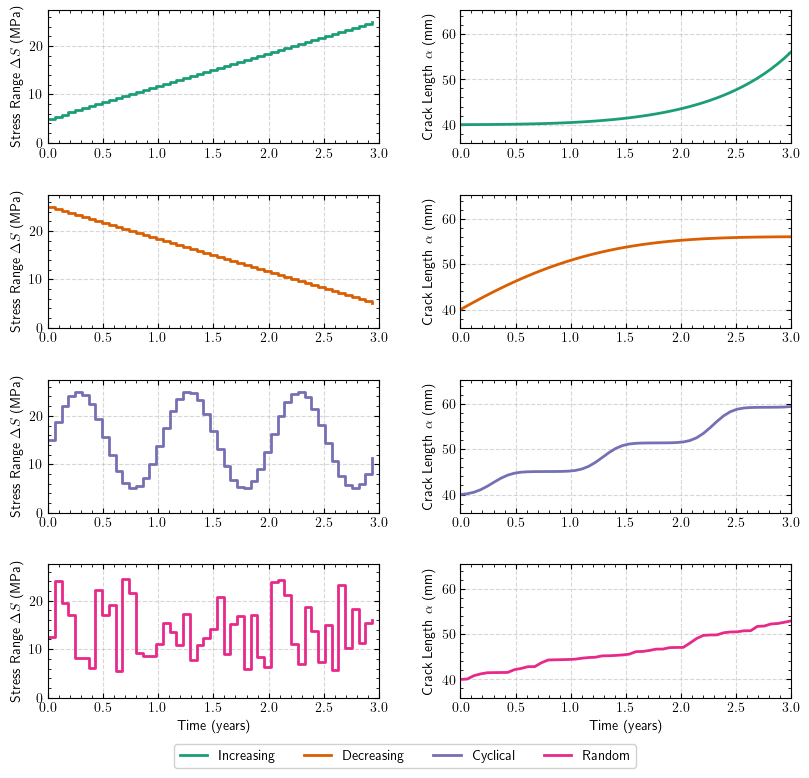

In [22]:
from src.visualisation import plot_stress_pattern_comparison

# Set parameters
logc = np.log(5e-14)  # Natural log of Paris law C parameter
m = 3.2               # Paris law exponent m
navg = 2.8e6          # Average cycles per year
a0 = 40.0             # Initial crack length (mm)

# Use the new function to create the comparison plot
fig, axes = plot_stress_pattern_comparison(
    logc=logc,
    m=m,
    navg=navg,
    a0=a0,
    min_stress=5.0,
    max_stress=25.0,
    patterns=['increasing', 'decreasing', 'cyclical', 'random'],
    cmap_name='Dark2',
    figsize=(8.2, 8.2),
    save_fig_name="stress_pattern_comparison.pdf"
)

# Print analysis of the results
# print("Final crack lengths with varying stress patterns:")
# for pattern, length in stats['final_lengths'].items():
#     print(f"{pattern.capitalize():<12}: {length:.2f} mm")

# print("\nAverage stress for each pattern:")
# for pattern, avg_stress in stats['avg_stresses'].items():
#     print(f"{pattern.capitalize():<12}: {avg_stress:.2f} MPa")

# print("\nEffect of stress pattern (Length/Stress ratio):")
# for pattern, ratio in stats['length_stress_ratio'].items():
#     print(f"{pattern.capitalize():<12}: {ratio:.2f}")

# # Explanation of why patterns with same average stress produce different results
# print("\nObservation: Even with the same average stress, patterns produce")
# print(r"different final crack lengths because of the power law $(da/dN ∝ \Delta K^m)$.")
# print(f"When $m > 1$ (here m = {m:.1f}), high stress periods contribute")
# print("disproportionately more to crack growth than low stress periods.")


## Visualizing Selected Crack Growth Trajectories

Here we demonstrate the new functions for visualizing selected trajectories and observations.

In [23]:
# Import our new trajectory selector and observation generator
from src.data_utils import TrajectorySelector, CrackObservationGenerator
from src.visualisation import plot_selected_trajectories, plot_trajectories_with_observations

In [24]:
# First, let's select some trajectories with similar Paris law parameters
trajectory_selector = TrajectorySelector(data)

# Set target parameters for selection (similar to what we did in the HBM_for_SCG notebook)
# This will internally calculate target parameters based on the data statistics
trajectory_selector._set_target_parameters(scale_logc=-1.5, scale_m=1.5)

# Select trajectories that are within 1% of the standard deviation from the targets
selected_indices = trajectory_selector.select_by_radius(radius=0.01)
print(f"Found {len(selected_indices)} trajectories matching the criteria")

# Extract the selected trajectories
selected_trajectories = trajectory_selector.extract_trajectories(selected_indices)

# Print Paris parameters of selected trajectories
print("Paris parameters of selected trajectories:")
for i, (c, m) in enumerate(zip(selected_trajectories['paris_c'], selected_trajectories['paris_m'])):
    print(f"Trajectory {i+1}: C={c:.2e}, m={m:.4f}")

Found 3 trajectories matching the criteria
Paris parameters of selected trajectories:
Trajectory 1: C=4.80e-14, m=3.2491
Trajectory 2: C=4.82e-14, m=3.2482
Trajectory 3: C=4.79e-14, m=3.2494


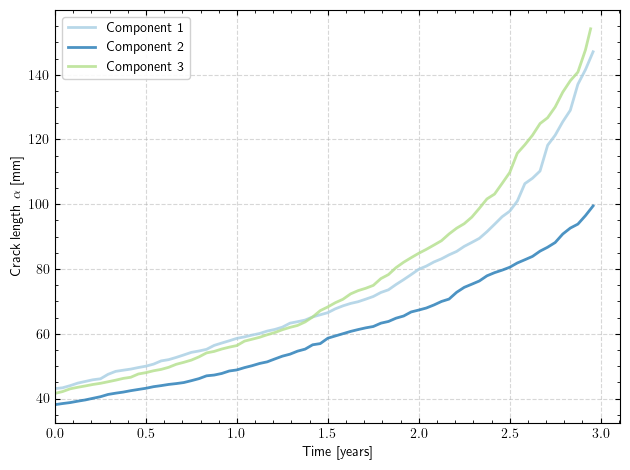

In [25]:
# Visualize the selected trajectories
fig, ax = plot_selected_trajectories(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    alpha=0.8,
    save_fig_name="selected_trajectories_pm.pdf"
)

## Simulating and Visualizing Crack Observations

Now let's generate simulated observations from these trajectories and visualize them.

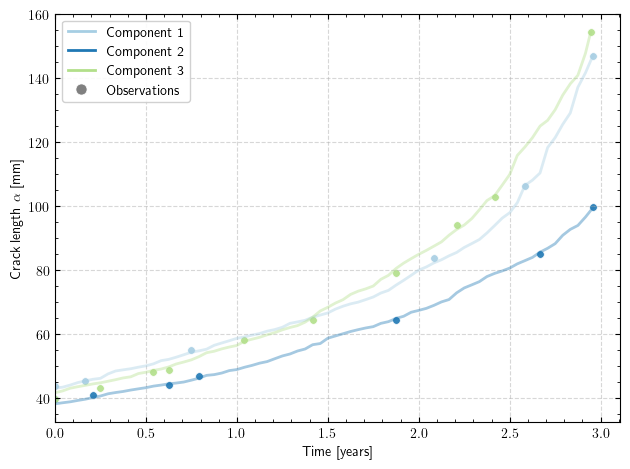

In [26]:
# Create an observation generator based on the selected trajectories
obs_generator = CrackObservationGenerator(selected_trajectories, random_seed=42)

# Generate observations using random sampling with noise
observations = obs_generator.create_observations(
    n_points=[6, 7, 10],           # 10 observations per trajectory
    strategy='random',     # Random sampling across the timeline
    std_dev=1.0,           # 1mm standard deviation measurement noise
    include_endpoints=True,  # Always include start and end points
    random_seed=42
)

# Visualize the trajectories with observations
fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=observations['times'],
    obs_lengths=observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.4,        # Make the trajectories slightly transparent
    obs_alpha=0.9,         # Make the observations more visible
    marker_size=30,        # Increase marker size for visibility
    save_fig_name="trajectories_with_observations.pdf"
)

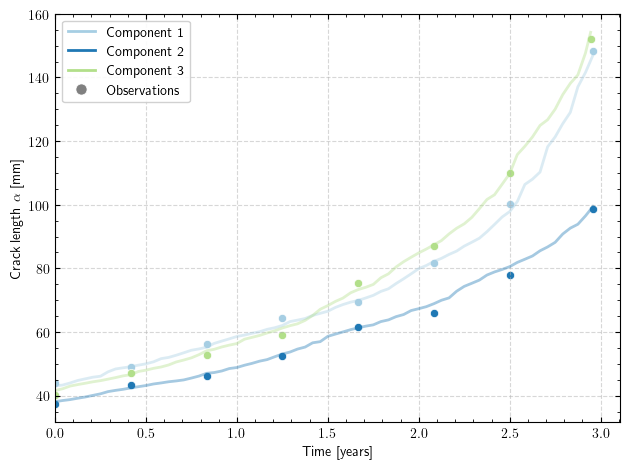

In [27]:
# Let's also try uniform sampling, which is more systematic
uniform_observations = obs_generator.create_observations(
    n_points=8,            # 8 observations per trajectory
    strategy='uniform',    # Evenly spaced observations
    std_dev=1.5,           # Slightly higher noise for demonstration
    include_endpoints=True,
    random_seed=42
)

# Visualize with uniform sampling
fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=uniform_observations['times'],
    obs_lengths=uniform_observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.4,
    obs_alpha=1.0,
    marker_size=35,
    save_fig_name="uniform_observations.pdf"
)

# Add title to indicate this is uniform sampling
# ax.set_title("Crack Growth Trajectories with Uniformly Sampled Observations")

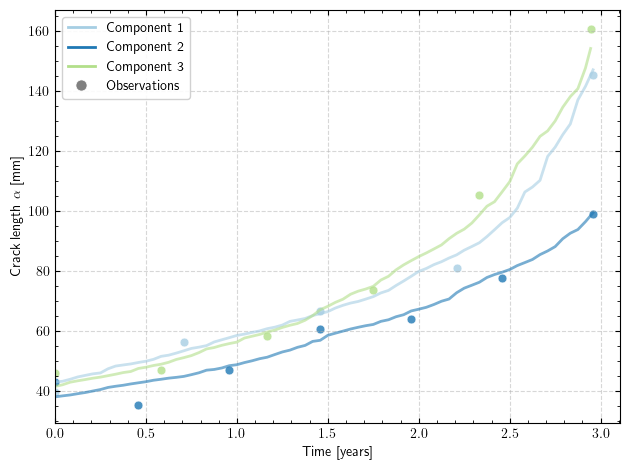

In [28]:
# Finally, let's demonstrate different noise levels
# Higher noise to illustrate measurement uncertainty
high_noise_observations = obs_generator.create_observations(
    n_points=[5, 7, 6],    # Different number of points for each trajectory
    strategy='uniform',
    std_dev=3.0,           # Higher noise level
    include_endpoints=True,
    random_seed=123
)

fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=high_noise_observations['times'],
    obs_lengths=high_noise_observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.6,
    obs_alpha=0.8,
    marker_size=40,
    save_fig_name="high_noise_observations.pdf"
)

# Add title to indicate the high noise level
# ax.set_title(r"Crack Growth Trajectories with High Measurement Uncertainty ($\sigma = 3.0$ mm)")

# Add text to explain what's being shown
# ax.text(0.02, 0.02, 
#         "Solid lines: True crack growth trajectories\nPoints: Simulated measurements with noise", 
#         transform=ax.transAxes, 
#         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'),
#         fontsize=9)

## Bayesian Inference for Crack Growth Parameters

In this section, we'll use the Bayesian model we've implemented to infer Paris law parameters from observed crack growth data. We'll start with a single component and then expand to multiple components.

In [29]:
import numpyro.distributions as dist
from src.bayesian_models import STLBayesianModel
from src.visualisation import plot_posterior_trace

# Set a seed for reproducibility
np.random.seed(42)

In [90]:
# First, let's define our priors for the model
# These priors are based on domain knowledge about Paris law parameters
priors = {
    "logc": dist.Normal(-30.0, 2.0),      # Natural log of C parameter
    "m": dist.Normal(3.2, 0.5),           # Paris law exponent
    "ds": dist.Weibull(14.9, 1.6),           # Stress range (MPa)
    "noise_std": dist.HalfNormal(2.0)     # Observation noise (mm)
}

# Component index to start with
component_idx = 2

# Extract the true parameters for this component from the selected trajectories
true_logc = np.log(selected_trajectories['paris_c'][component_idx])
true_m = selected_trajectories['paris_m'][component_idx]
true_a0 = selected_trajectories['initial_crack_length'][component_idx]

print(f"True parameters for component {component_idx + 1}:")
print(f"logC: {true_logc:.4f}")
print(f"m: {true_m:.4f}")
print(f"a0: {true_a0:.4f}")

True parameters for component 3:
logC: -30.6687
m: 3.2494
a0: 41.5960


In [91]:
# Create the Bayesian model
# We'll use the uniform observations we created earlier
model = STLBayesianModel(priors=priors, crack_growth_data=uniform_observations)

# Run inference with MCMC
# For demonstration, we're using fewer samples than we would in practice
results = model.run_inference(
    component_idx=component_idx,
    navg = 2.8e6,       # Average cycles per year
    num_warmup=2000,    # Number of warmup steps
    num_samples=2000,   # Number of samples to draw
    num_chains=4,       # Number of chains to run
    progress_bar=True   # Show progress bar during sampling
)

/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(
sample: 100%|██████████| 4000/4000 [00:02<00:00, 1902.65it/s, 415 steps of size 2.49e-03. acc. prob=0.88] 


In [92]:
# Print full posterior summary
model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:")
print(f"Inferred logC: {results['summary']['mean']['logc']:.4f} ± {results['summary']['sd']['logc']:.4f}")
print(f"Inferred m: {results['summary']['mean']['m']:.4f} ± {results['summary']['sd']['m']:.4f}")
print(f"Inferred noise_std: {results['summary']['mean']['noise_std']:.4f} ± {results['summary']['sd']['noise_std']:.4f}")

                               mean     sd   hdi_3%  hdi_97%  mcse_mean  \
ds                           10.882  5.064    3.180   20.821      0.134   
logc                        -30.516  1.688  -33.637  -27.368      0.044   
m                             3.790  0.192    3.424    4.138      0.005   
noise_std                     2.284  0.635    1.321    3.514      0.018   
predicted_crack_lengths[0]   45.384  0.212   45.016   45.804      0.005   
predicted_crack_lengths[1]   52.099  0.460   51.288   53.000      0.012   
predicted_crack_lengths[2]   60.815  0.736   59.510   62.259      0.019   
predicted_crack_lengths[3]   72.493  1.014   70.681   74.472      0.025   
predicted_crack_lengths[4]   88.780  1.223   86.447   91.039      0.029   
predicted_crack_lengths[5]  112.700  1.284  110.430  115.280      0.022   
predicted_crack_lengths[6]  150.362  2.265  146.260  154.787      0.034   

                            mcse_sd  ess_bulk  ess_tail  r_hat  
ds                            0.09

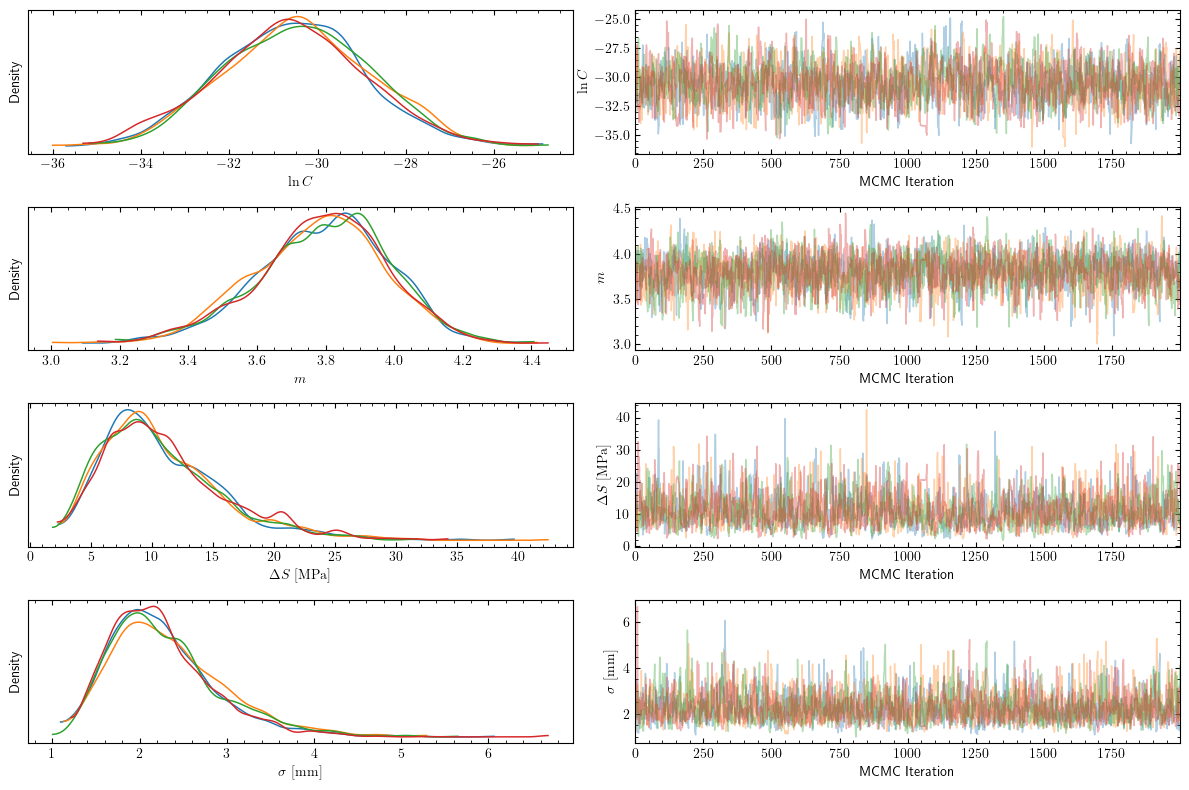

In [93]:
# Visualize posterior distributions
var_names = ["logc", "m", "ds", "noise_std"]
plot_var_names= [r"$\ln C$",  r"$m$", r"$\Delta S \ \mathrm{[MPa]}$", r"$\sigma \ \mathrm{[mm]}$"]
plot_posterior_trace(results['samples'], var_names=var_names, plot_var_names=plot_var_names,
                      save_fig_name="posterior_traces_stl_c3.pdf")

## Comparing Prior and Posterior Distributions

We can use the new `plot_prior_posterior_comparison` function to visualize both prior and posterior distributions alongside the true parameter values and the posterior mode.

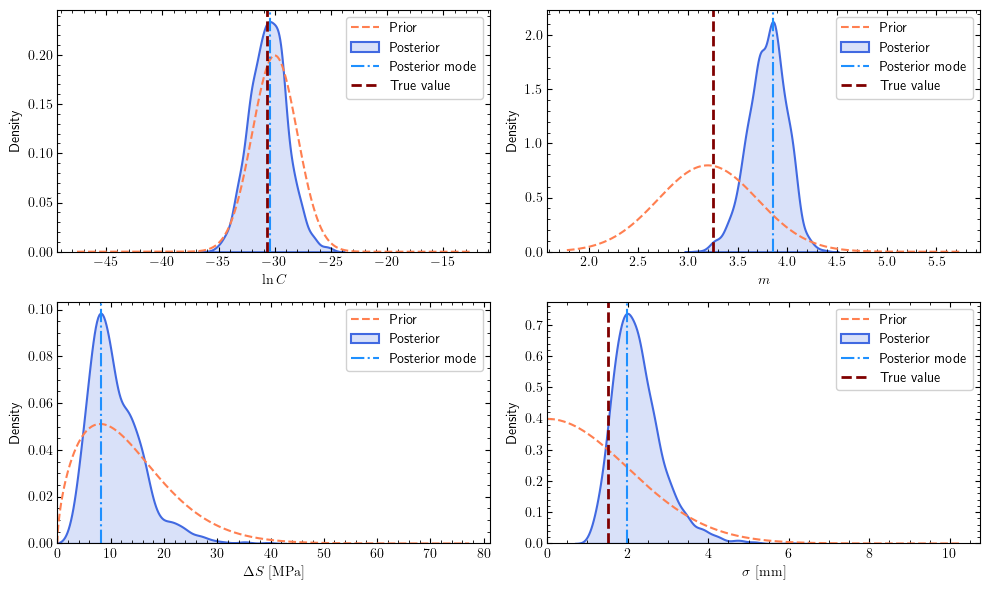

In [94]:
# Import necessary modules
import numpy as np
import numpyro.distributions as dist
from src.visualisation import plot_prior_posterior_comparison

# # Define the priors (same as used in the model)
# priors = {
#     "logc": dist.Normal(-30.0, 2.0),      # Natural log of C parameter
#     "m": dist.Normal(3.2, 0.5),           # Paris law exponent
#     "ds": dist.Gamma(5.0, 0.3),           # Stress range (MPa)
#     "noise_std": dist.HalfNormal(2.0)     # Observation noise (mm)
# }

# Define the true values (for demonstration)
true_values = {
    "logc": true_logc,
    "m": true_m,
    "noise_std": 1.5  # Noise used in generating observations
}

# Extract posterior samples
posterior_samples = results['samples']

# Define nice display names for plotting
plot_labels = {
    "logc": r"$\ln C$",
    "m": r"$m$",
    "ds": r"$\Delta S \ \mathrm{[MPa]}$",
    "noise_std": r"$\sigma \ \mathrm{[mm]}$"
}

# Create the comparison plot with extended prior range for better visualization
fig, axes = plot_prior_posterior_comparison(
    posterior_samples=posterior_samples,
    prior_dists=priors,
    true_values=true_values,
    var_names=var_names,
    plot_var_names=plot_labels,
    figsize=(10.0, 6.0),
    n_cols=2,
    point_estimate='mode',
    save_fig_name="prior_posterior_comparison_stl_c3.pdf",
    use_first_chain_only=True,
    prior_range_extension=2.5
)

In [95]:
# Generate predictions from the posterior
posterior_predictions = model.generate_predictions(
    num_samples=1000,  # Use 100 samples for more efficient visualization
    component_idx=component_idx,
    navg=2.8e6,
    random_seed=42
)

In [96]:
# Use the new visualization function to plot posterior predictive samples
from src.visualisation import plot_posterior_predictive_stl

# Get times and data for plotting
true_times = selected_trajectories['times'][component_idx]
true_crack_lengths = selected_trajectories['crack_lengths'][component_idx]
observed_times = uniform_observations['times'][component_idx]
observed_crack_lengths = uniform_observations['noisy_crack_lengths'][component_idx]



Comparison of statistics:
Predictions RMSE: 1.909 mm
Observations RMSE: 1.947 mm

95% CI width at final time:
Predictions: 8.62 mm
Observations: 12.51 mm


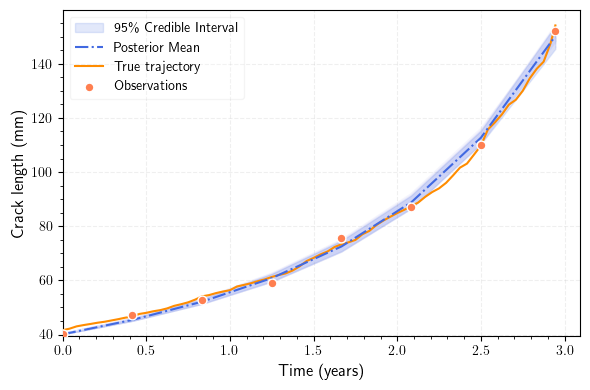

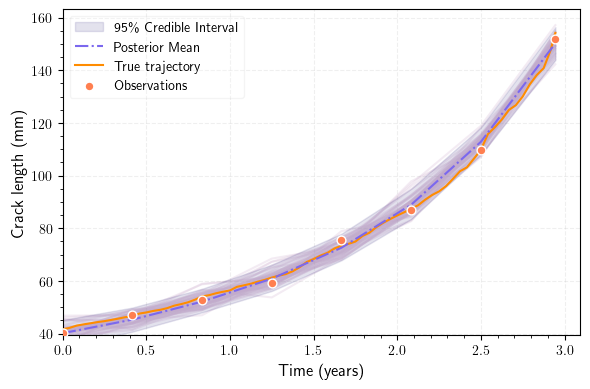

In [97]:
# Generate predictions using the proper posterior predictive sampling method
posterior_predictive_output = model.generate_posterior_predictive(
    num_samples=1000,
    component_idx=component_idx,
    navg=2.8e6,
    random_seed=42
)

# Plot the predicted crack lengths (default behavior)
fig1, ax1, stats1 = plot_posterior_predictive_stl(
    posterior_predictions=posterior_predictive_output,
    true_times=true_times,
    true_crack_lengths=true_crack_lengths,
    observed_times=observed_times,
    observed_crack_lengths=observed_crack_lengths,
    max_samples=50,
    figsize=(6, 4),
    save_fig_name="posterior_predictive_predictions_stl_c3.pdf"
)

# Plot only the observations with noise
fig2, ax2, stats2 = plot_posterior_predictive_stl(
    posterior_predictions=posterior_predictive_output,
    true_times=true_times,
    true_crack_lengths=true_crack_lengths,
    observed_times=observed_times,
    observed_crack_lengths=observed_crack_lengths,
    max_samples=50,
    figsize=(6, 4),
    plot_type="observations",  # Plot observations instead of predictions
    save_fig_name="posterior_predictive_observations_stl_c3.pdf"
)

# Print comparison of statistics
print("\nComparison of statistics:")
print(f"Predictions RMSE: {stats1['rmse']:.3f} mm")
print(f"Observations RMSE: {stats2['rmse']:.3f} mm")

print("\n95% CI width at final time:")
print(f"Predictions: {stats1['ci_width'][-1]:.2f} mm")
print(f"Observations: {stats2['ci_width'][-1]:.2f} mm")


## Using the Output Utilities Module for Parameter Comparison

We'll use the new `output_utils` module to calculate error metrics and create formatted comparison tables for our Bayesian inference results across different components.

In [39]:
from src.output_utils import calculate_component_metrics, format_comparison_table, save_results_table

# Now let's run the model on all three components to compare performance
component_results = []

for i in range(len(selected_indices)):
    print(f"\nRunning inference for component {i+1}...")
    
    # Extract true parameters
    true_logc = np.log(selected_trajectories['paris_c'][i])
    true_m = selected_trajectories['paris_m'][i]
    true_a0 = selected_trajectories['initial_crack_length'][i]
    
    print(f"True parameters for component {i + 1}:")
    print(f"logC: {true_logc:.4f}")
    print(f"m: {true_m:.4f}")
    print(f"a0: {true_a0:.4f}")
    
    # Create a new model for each component
    # For efficiency, use fewer samples for this comparison
    model = STLBayesianModel(priors=priors, crack_growth_data=uniform_observations)
    results = model.run_inference(
        component_idx=i,
        num_warmup=500,
        num_samples=1000,
        num_chains=2,
        progress_bar=True
    )
    
    # Store results
    component_results.append({
        'index': i,
        'true_params': {
            'logc': true_logc,
            'm': true_m,
            'a0': true_a0,
            'noise_std': 1.5  # The true noise std used for generating observations
        },
        'inferred_params': {
            'logc': results['summary']['mean']['logc'],
            'logc_sd': results['summary']['sd']['logc'],
            'm': results['summary']['mean']['m'],
            'm_sd': results['summary']['sd']['m'],
            'ds': results['summary']['mean']['ds'],
            'ds_sd': results['summary']['sd']['ds'],
            'noise_std': results['summary']['mean']['noise_std'],
            'noise_std_sd': results['summary']['sd']['noise_std']
        }
    })

# Use our new output_utils module to create the comparison table
comparison_df = calculate_component_metrics(component_results)

# Format the table with 4 decimal places
formatted_df = format_comparison_table(comparison_df, precision=4)

# Display the results
print("\nComparison of true vs inferred parameters with multiple metrics:")
formatted_df

/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(



Running inference for component 1...
True parameters for component 1:
logC: -30.6669
m: 3.2491
a0: 43.0770


sample: 100%|██████████| 1500/1500 [00:00<00:00, 2525.47it/s, 511 steps of size 4.22e-03. acc. prob=0.92]
/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(



Running inference for component 2...
True parameters for component 2:
logC: -30.6630
m: 3.2482
a0: 38.1200


sample: 100%|██████████| 1500/1500 [00:00<00:00, 2541.86it/s, 1023 steps of size 4.38e-03. acc. prob=0.94]
/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:151: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(



Running inference for component 3...
True parameters for component 3:
logC: -30.6687
m: 3.2494
a0: 41.5960


sample: 100%|██████████| 1500/1500 [00:00<00:00, 1895.98it/s, 1023 steps of size 1.73e-03. acc. prob=0.98]



Comparison of true vs inferred parameters with multiple metrics:


,Component,True logc,Inferred logc,logc SD,True m,Inferred m,m SD,True noise_std,Inferred noise_std,noise_std SD,logc MAPE (%),logc RMSE,m MAPE (%),m RMSE,noise_std MAPE (%),noise_std RMSE
0,1,-30.6669,-31.633,1.650,3.2491,3.977,0.374,1.5,4.491,0.959,3.1502,0.9661,22.4031,0.7279,199.4000,2.9910
1,2,-30.6630,-30.505,1.554,3.2482,3.502,0.286,1.5,2.191,0.597,0.5153,0.1580,7.8136,0.2538,46.0667,0.6910
2,3,-30.6687,-31.062,1.539,3.2494,3.760,0.191,1.5,2.352,0.689,1.2825,0.3933,15.7137,0.5106,56.8000,0.8520
3,Average,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6493,0.5058,15.3101,0.4974,100.7556,1.5113


In [43]:
# Save the results to a CSV file
save_path = save_results_table(formatted_df, "component_comparison_results")
print(f"\nResults saved to: {save_path}")


Results saved to: /Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/outputs/component_comparison_results.csv


In [75]:
# We can also use the posterior prediction metrics to evaluate model performance
from src.output_utils import calculate_prediction_metrics

for i, component_idx in enumerate(range(len(selected_indices))):
    # Generate posterior predictive samples for this component
    posterior_predictive_output = model.generate_posterior_predictive(
        num_samples=100,
        component_idx=component_idx,
        navg=2.8e6,
        random_seed=42
    )
    
    # Extract true and observed data for this component
    true_times = selected_trajectories['times'][component_idx]
    true_crack_lengths = selected_trajectories['crack_lengths'][component_idx]
    observed_times = uniform_observations['times'][component_idx]
    observed_crack_lengths = uniform_observations['noisy_crack_lengths'][component_idx]
    
    # Calculate mean prediction from posterior samples
    pred_samples = posterior_predictive_output['predicted_crack_lengths']
    pred_mean = np.mean(pred_samples, axis=0)
    
    # Calculate metrics for prediction quality
    metrics = calculate_prediction_metrics(observed_crack_lengths, pred_mean)
    
    print(f"\nComponent {i+1} prediction metrics:")
    print(f"RMSE: {metrics['rmse']:.4f} mm")
    print(f"MAE: {metrics['mae']:.4f} mm")
    print(f"R²: {metrics['r_squared']:.4f}")
    print(f"MAPE: {metrics['mape']:.2f}%")


Component 1 prediction metrics:
RMSE: 23.3966 mm
MAE: 16.2843 mm
R²: 0.4643
MAPE: 16.53%

Component 2 prediction metrics:
RMSE: 12.7167 mm
MAE: 8.5278 mm
R²: 0.5521
MAPE: 11.09%

Component 3 prediction metrics:
RMSE: 1.9087 mm
MAE: 1.6576 mm
R²: 0.9971
MAPE: 2.16%
